# 09 - Advanced Analysis: Normalization, Scaling, And Fits

This notebook introduces analysis workflows that transform or fit a series of CVs. It starts with physical dimensionless normalization, standardized current, and `i/ip0` normalized current, then moves into peak fits, plateau-current analysis, FOWA, rate fitting, and Tafel-style analysis.

Reversibility, Sevcik, Nicholson, and trumpet workflows now live together in `07_reversibility_analysis.ipynb`, before these more advanced transformations and catalytic analyses. Replace placeholder constants, fit windows, and mechanistic assumptions before interpreting any result.

## Import eCAT And Set Paths

The setup is intentionally short now that notebooks 00-02 have introduced the pattern.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

import ecat as e

DATA_DIR = ROOT / "examples" / "data" / "fe_phoh_cv"
EXPORT_DIR = ROOT / "notebooks" / "_outputs"
EXPORT_DIR.mkdir(exist_ok=True)

e.plotting_style("notebook")
plt.rcParams["figure.max_open_warning"] = 0
print("eCAT version:", getattr(e, "__version__", "unknown"))
print("Example data:", display_path(DATA_DIR))
print("Text files:", len(list(DATA_DIR.glob("*.txt"))))


eCAT version: 0.1.0b4
Example data: examples/data/fe_phoh_cv
Text files: 13


## Load, Inspect, And Select Analysis Series

The advanced-analysis examples need reference-corrected CVs, scan-rate metadata, and electrode area metadata. The reference correction uses Fc/Fc+ keyword matching. One trace in this sample set has a less reliable self-reference at high PhOH concentration, so the import includes a small `reference map`: before filtering, object `12` is the 2.8 M PhOH CV and object `11` is the 1 M PhOH CV, so `12: 11` tells eCAT to use the 1 M reference assignment for the 2.8 M trace.

`electrode diameter` is included during import so eCAT can store electrode area on each CV; `normalize()` can then use that metadata automatically. After import, the multiscan file is removed with a public `segments` filter so the analysis series contain only ordinary 3-segment CVs.


In [2]:
cvs = e.get_data({
    "folder path": str(DATA_DIR),
    "reference mode": "keyword",
    "reference keyword": "Fc",
    "reference guess": 0.4,
    "reference label": "Fc/Fc+",
    "reference map": {12: 11},
    "electrode diameter": 0.3,
    "print": True,
})
cvs = e.filter(cvs, {"segments": 3}, {"print": False})


Searching recursively through:
 examples/data/fe_phoh_cv
13 supported text files found.

Reference correction:
  Mode: keyword
  Keyword: Fc
  Guess: 0.4 V
  Folder reference: `MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs.txt` = 0.4665 V
  Usage:
    folder/ancestor reference: 1
    self-referenced successfully: 11
    explicit reference map: 1

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆
[Reference] Label: Fc/Fc+


,Gas,Compounds,Scan Window,Scan Rate,Segments,Reference Shift,Reference Mode,Reference Source
[0],Ar,,"[-1.2, 1]",100 mV/s,3,0.467,folder,[1]
[1],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s,3,0.467,self,[1]
[2],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",100 mV/s,3,0.467,self,[2]
[3],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",25 mV/s,3,0.467,self,[3]
[4],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",500 mV/s,3,0.466,self,[4]
[5],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",1 V/s,3,0.466,self,[5]
[6],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",50 mV/s,3,0.467,self,[6]
[7],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s,3,0.467,self,[7]
[8],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 100 mM PhOH","[-1.2, 1]",100 mV/s,3,0.466,self,[8]
[9],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 560 mM PhOH","[-1.2, 1]",100 mV/s,3,0.468,self,[9]


In [3]:
blank = e.filter(cvs, {
    "gas": "Ar",
    "compounds": ["Fc", "Fe-tpyPY2Me"],
}, {"logic": "AND", "mode": "exclude", "print": False})[0]

fe_100 = e.filter(cvs, {
    "scan rate": 0.1,
    "scan window": [-1.2, 1],
    "compounds": "Fe-tpyPY2Me",
}, {"logic": "AND", "print": False})

fe_ar = e.filter(cvs, {
    "gas": "Ar",
    "compounds": "Fe-tpyPY2Me",
}, {"logic": "AND", "print": False})

co2_cvs = e.filter(cvs, {
    "gas": "CO2",
}, {"print": False})

co2_only = e.filter(co2_cvs, {
    "compounds": "PhOH",
}, {"mode": "exclude", "print": False})[0]

phoh_co2 = e.filter(co2_cvs, {
    "compounds": "PhOH",
}, {"print": False})
high_phoh = [obj for obj in phoh_co2 if "2.8MPhOH" in obj.name][0]
co2_titration = [co2_only] + phoh_co2

scan_series = e.filter(fe_ar, {
    "scan window": [-1.7, 1],
}, {"print": False})
scan_series = e.sort(scan_series, "scan rate", {"print": False})

target = phoh_co2[0]

e.show_objects(scan_series);


[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %


,Scan Rate
[0],25 mV/s
[1],50 mV/s
[2],100 mV/s
[3],500 mV/s
[4],1 V/s


## Plot The Scan-Rate Series With A Colorbar

Before fitting a scan-rate series, plot it. This is the quickest check that the same feature is being tracked across the series, the scan windows match, and no trace has an obvious import or current-direction problem. Here `multiplot()` uses a colorbar instead of a long legend because scan rate is an ordered variable.


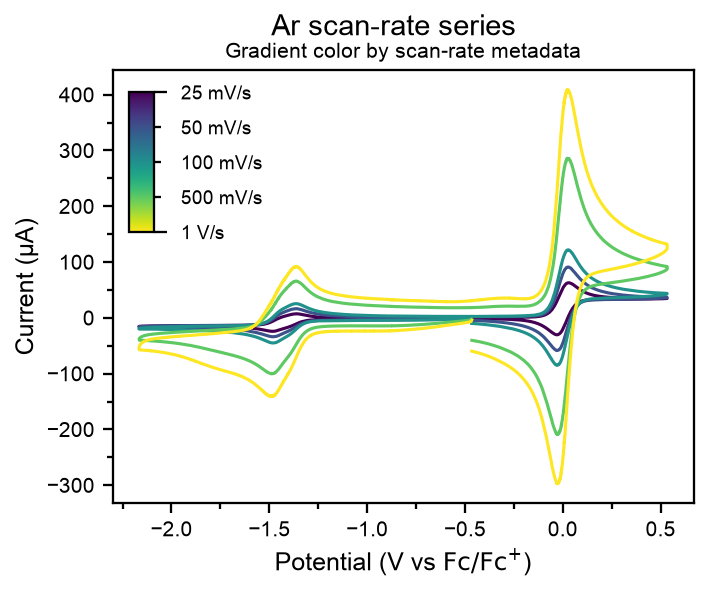

In [4]:
ax = e.multiplot(scan_series, {
    "print": False,
    "title": "Ar scan-rate series",
    "subtitle": "Gradient color by scan-rate metadata",
    "legend mode": "colorbar",
    "colorbar tick labels": "all",
    "gradient scale": "index",
    "colorbar height": 2.5,
})
# ax.figure.savefig(EXPORT_DIR / "advanced_scan_rate_series.png", dpi=300, bbox_inches="tight")

## Physical Dimensionless Normalization With `normalize()`

`normalize()` returns copied CVs with dimensionless potential and/or current axes. For a scan-rate series, eCAT can read the scan rate from each CV and use the electrode area stored during import. The values below are placeholders: replace `D`, `C`, `n`, `E0`, and `temperature` with values that are appropriate for your system.

When `print` is on for a series, eCAT prints the symbolic equation once, reports the shared mode outside the table, and shows one parameter table with group-index columns.

Mode: homogeneous


<IPython.core.display.Math object>

<IPython.core.display.Math object>

,0,1,2,3,4
Parameter,,,,,
n,2.000,2.000,2.000,2.000,2.000
T / K,298.0,298.0,298.0,298.0,298.0
E0 / V,0.000,0.000,0.000,0.000,0.000
D / cm2 s-1,1.000e-05,1.000e-05,1.000e-05,1.000e-05,1.000e-05
C* / mol cm-3,1.000e-06,1.000e-06,1.000e-06,1.000e-06,1.000e-06
C* input,1 mM,1 mM,1 mM,1 mM,1 mM
S / cm2,0.07069,0.07069,0.07069,0.07069,0.07069
ν / V s-1,0.02500,0.05000,0.1000,0.5000,1.000


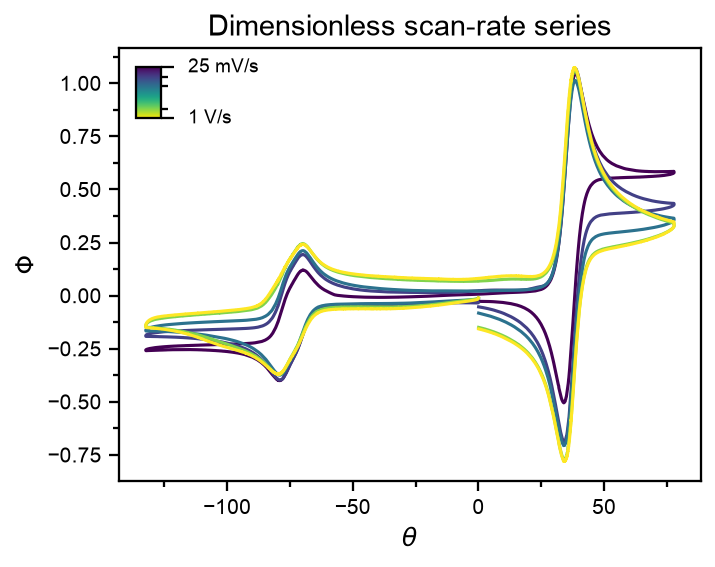

In [5]:
normalized_scan_series = e.normalize(scan_series, {
    "mode": "homogeneous",
    "D": 1e-5,
    "C": "1 mM",
    "n": 2,
    "E0": 0,
    "temperature": 298,
    "print": True,
})
e.multiplot(normalized_scan_series, {
    "title": "Dimensionless scan-rate series",
});

## Standardize Current With `scale_current()`

`scale_current()` returns copied CVs whose raw current columns have been multiplied by scale factors. This is useful when you want to compare waveform shape after matching a reference peak or manually chosen current scale. It is not the same as `i/ip0`: the current is still in current units, just scaled.

Here the CO2/no-PhOH trace is used as the reference CV for the CO2 titration. eCAT extracts the reference current with peak-current settings, computes scale factors, and returns scaled copies that can be passed straight to `multiplot()`.

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


,Gas,Compounds,Scale Factor
[0],Ar,,1.000
[1],CO2,,0.8163
[2],CO2,100 mM PhOH,0.6853
[3],CO2,560 mM PhOH,0.7268
[4],CO2,1 M PhOH,0.8189
[5],CO2,2.8 M PhOH,1.133


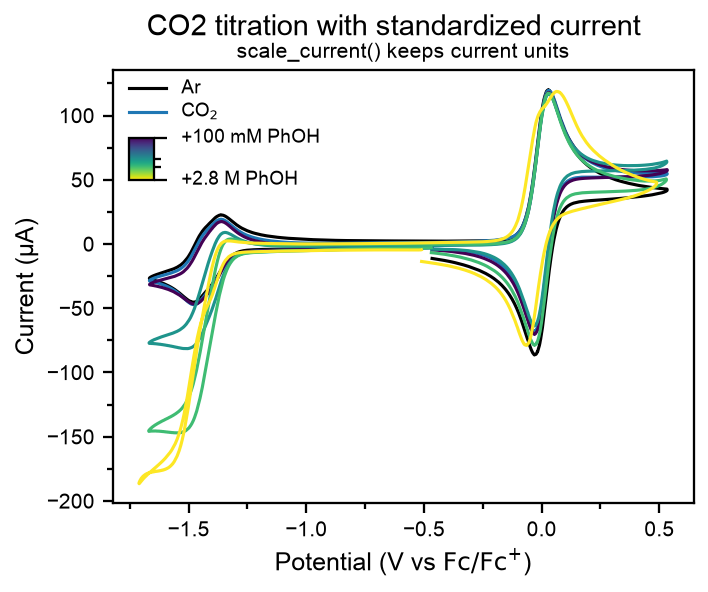

In [6]:
standardized_titration = e.scale_current(fe_100, {
    "reference cv": fe_100[0],
    "reference mode": "single",
    "segment": 2,
    "guess potential": 0,
    "print": True,
})

e.multiplot(standardized_titration, {
    "title": "CO2 titration with standardized current",
    "subtitle": "scale_current() keeps current units",
});

## Normalize Current As `i/ip0` With `normalize_current()`

`normalize_current()` returns copied CVs with a stored `i/ip0` axis. This is the dimensionless current-ratio workflow used when a non-catalytic reference current is the natural scale. Compared with `scale_current()`, the y-axis is no longer current in amperes; it is a ratio to `ip0`.

For this PhOH titration, use the CO2/no-PhOH CV as the non-catalytic reference. The normalized copies still behave like CVs, so `multiplot()` automatically uses the normalized y-axis unless you explicitly ask for raw `Current`.

Current Normalization:
CVs: 5
ip0: -5.117e-05 A
Source: reference CV: MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs


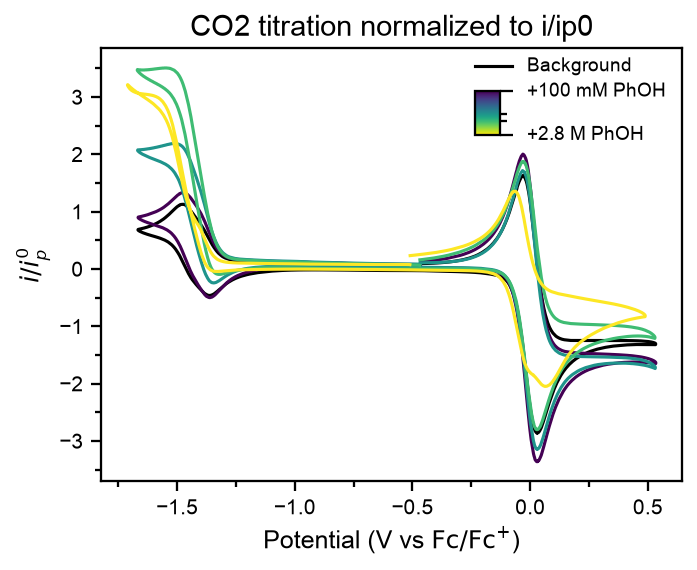

In [7]:
normalized_titration = e.normalize_current(co2_titration, {
    "reference cv": co2_only,
    "guess potential": -1.5,
    "print": True,
})

e.multiplot(normalized_titration, {
    "title": "CO2 titration normalized to i/ip0",
    "legend": True,
});

## Fit Peak Current With `fit_peak_current`

`fit_peak_current()` extracts a peak current from each CV, resolves the varying x-axis automatically, and fits the resulting trend. For scan-rate series, the default x transform is useful for Randles-Sevcik-style behavior because peak current commonly scales with the square root of scan rate. Use this as a fast diagnostic before deciding whether a full Sevcik analysis is justified.


[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %


,Plot Label,Scan Rate
[0],25 mV/s,25 mV/s
[1],50 mV/s,50 mV/s
[2],100 mV/s,100 mV/s
[3],500 mV/s,500 mV/s
[4],1 V/s,1 V/s


Field,Value
Model,linear
Equation,y = m x + b
Fit Parameters,"m, b (2)"
Residual,direct
X Range,0.158114 to 1.00000
Fit Points,5
R²,0.999273
RMSE,0.988720
m,-113.878 ± 1.77326
b,-4.13254 ± 1.02635


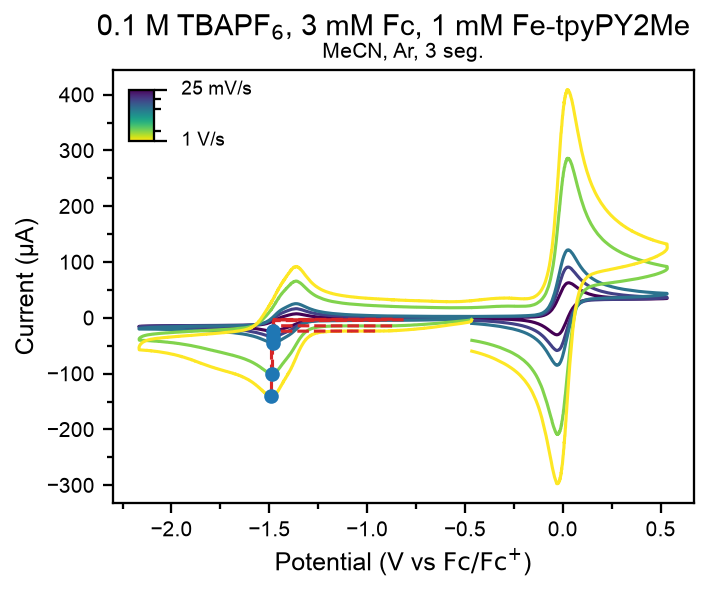

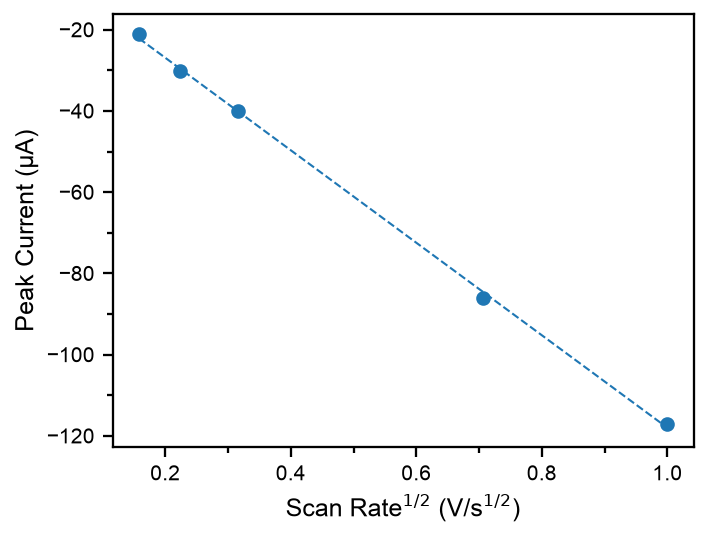

In [8]:
fit = e.fit_peak_current(scan_series, {
    "plot all": True,
    "plot fit": True,
    "fit label": True,
    "segment": 1,
    "print": True,
    "return stats": True,
})

## Fit Peak Potential With `fit_peak_potential`

`fit_peak_potential()` tracks where a selected feature appears as a series changes. In a scan-rate series, shifts in peak potential can flag kinetic limitations, uncompensated resistance, adsorption, or simply a feature-picking problem. The function is intentionally parallel to `fit_peak_current()`: it collects one value per CV, plots the trend, and returns a fit result object that can be displayed with `e.show()`.

Here the two main segments are fitted separately. `guess potential` gives the peak picker a starting feature; in real use, adjust it after inspecting the overlay above.


[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %


,Plot Label,Scan Rate
[0],25 mV/s,25 mV/s
[1],50 mV/s,50 mV/s
[2],100 mV/s,100 mV/s
[3],500 mV/s,500 mV/s
[4],1 V/s,1 V/s


Field,Seg 1 Ep,Seg 2 Ep,Seg 1-2 E1/2
Model,linear,linear,linear
Equation,y = m x + b,y = m x + b,y = m x + b
Fit Parameters,"m, b (2)","m, b (2)","m, b (2)"
Residual,direct,direct,direct
X Range,-1.60206 to 0.00000,-1.60206 to 0.00000,-1.60206 to 0.00000
Fit Points,5,5,5
R²,0.748847,0.155664,0.934232
RMSE,0.00170391,0.00102322,0.000448610
m,-0.00488344 ± 0.00163282,-0.000729215 ± 0.000980519,-0.00280633 ± 0.000429891
b,-1.48791 ± 0.00168898,-1.36421 ± 0.00101425,-1.42606 ± 0.000444678


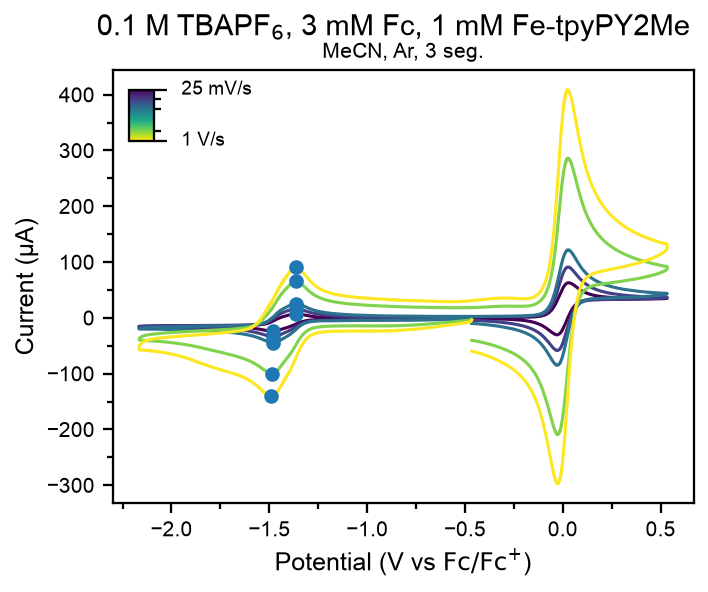

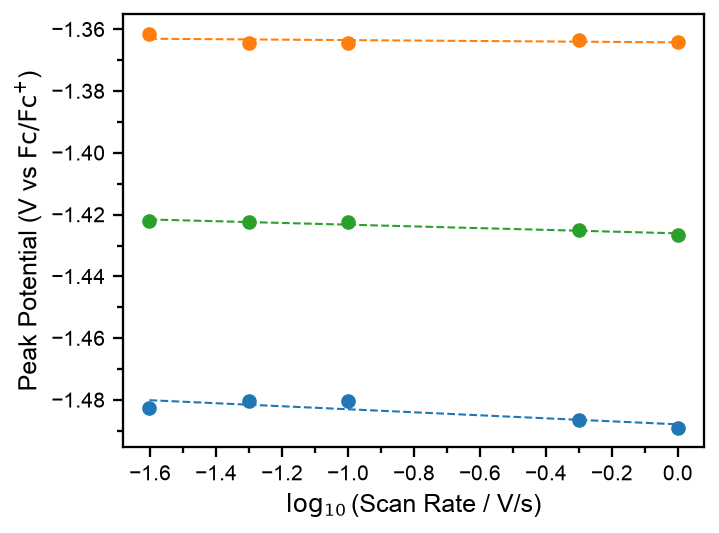

In [9]:
ep_fit = e.fit_peak_potential(scan_series, {
    "plot all": True,
    "plot": True,
    "plot fit": True,
    "fit label": True,
    "print": True,
    "segments": [1, 2],
    "guess potential": -1.5,
    "follow E1/2": True,
    "return stats": True,
})


## Plateau Current With `plateau_current()`

`plateau_current()` estimates a catalytic limiting or plateau current and can convert it into an observed rate constant when enough supporting assumptions are available. The cleanest use is a catalytic scan-rate series: eCAT can check whether the apparent plateau current is scan-rate independent before using it. Here we only have one 2.8 M PhOH CV, so this is a single-trace demonstration rather than a validated plateau-current workflow.

The 2.8 M trace is compared against the CO2/no-PhOH CV as the non-catalytic reference. `validate plateau` is turned off because one catalytic CV cannot test scan-rate independence; for publication-quality use, provide a scan-rate series or a manual `ilim` after inspecting the wave.


Parameter,Symbol,Value
Formula Mode,,normalized
Plateau Validation,,not tested
ilim,,150.2 μA (peak_current)
ip0,,-51.17 μA (non-catalytic cv)
ip0 Scan Rate,νip0,100.0 mV/s
Electrode Area,S,0.07069 cm^2
Catalyst Electrons,n,1.000
Turnover Electrons,n′,1.000
Temperature,T,298.0 K


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Metric,Value
kobs,6.673 s^-1
ilim,150.2 μA
ilim tangent,y = 2.642e-05x - 0.0001128
ip0,-51.17 μA
ilim/ip0,-2.935
ip0 tangent,y = 1.771e-06x - 3.940e-06
ip0 Scan Rate (ν_ip0),100.0 mV/s


{'data':                   Metric                       Value
 0                   kobs                  6.673 s^-1
 1                   ilim                    150.2 μA
 2           ilim tangent  y = 2.642e-05x - 0.0001128
 3                    ip0                   -51.17 μA
 4               ilim/ip0                      -2.935
 5            ip0 tangent  y = 1.771e-06x - 3.940e-06
 6  ip0 Scan Rate (ν_ip0)                  100.0 mV/s,
 'summary': {'analysis': 'plateau_current',
  'formula mode': 'normalized',
  'formula': "kobs = (0.446 |ilim/ip0| sqrt(n F v_ip0/RT))^2 / n'",
  'plateau validation': 'not tested',
  'valid plateau': None,
  'ilim': 0.00015019850613155088,
  'ilim source': 'peak_current',
  'ip0': -5.1174101495223625e-05,
  'ip0 source': 'non-catalytic cv',
  'ip0 scan rate': 0.1,
  'ip0 sqrt scan rate slope': None,
  'ip0 fit r2': nan,
  'D': None,
  'C': None,
  'electrode area': 0.07068583470577035,
  'catalyst electrons': 1.0,
  'turnover electrons': 1.0,
  'temper

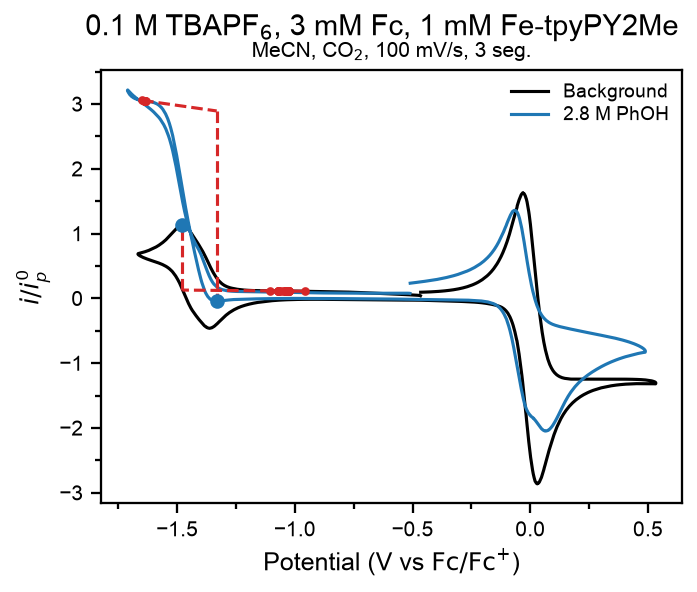

In [10]:
plateau = e.plateau_current(high_phoh, {
    "non-catalytic cv": co2_only,
    "guess potential": -1.5,
    "non-catalytic guess potential": -1.5,
    "validate plateau": False,
    "plot all": True,
    "print": True,
})

plateau


## FOWA With `fowa()`

Foot-of-the-wave analysis focuses on the low-overpotential region of a catalytic wave. It is useful when the catalytic response has a region where kinetic information can be extracted before mass transport, substrate depletion, or wave-shape complications dominate. The important user choices are the non-catalytic reference, the redox potential, and the fit region; the printed summary is meant to make those assumptions easy to audit.


[Conditions] Exp Type: CV, Solvent: MeCN, Gas: CO₂, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


Parameter,Symbol,Value
Reference CV,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs
ip0 Source,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs
Redox Source,,manual (-1.47 V)
Redox Potential,,-1.47
Segment,,1
Segment Selection,,default: segment 1
Background Correction,,tangent
Fit,,enabled
Fit Range,,"[0.1, 0.5]"
Mechanism,,EC'


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Compounds,Background Tangent,Wave Range,Fit Points,FOWA Fit,R2,Status,kobs / s-1
100 mM PhOH,y = 2.607e-06x - 2.784e-06,"[-1.213, -1.521]",67,y = 45.33x + 0.08534,0.9890,ok,1594.
560 mM PhOH,y = 2.363e-06x - 3.284e-06,"[-1.21, -1.536]",69,y = 69.10x + 0.08063,0.9943,ok,3704.
1 M PhOH,y = 3.078e-06x - 2.112e-06,"[-1.2145, -1.5745]",62,y = 68.78x + 0.06740,0.9971,ok,3669.
2.8 M PhOH,y = -3.441e-07x - 4.265e-06,"[-1.224, -1.71]",56,y = 18.03x + 0.05245,0.9964,ok,252.2


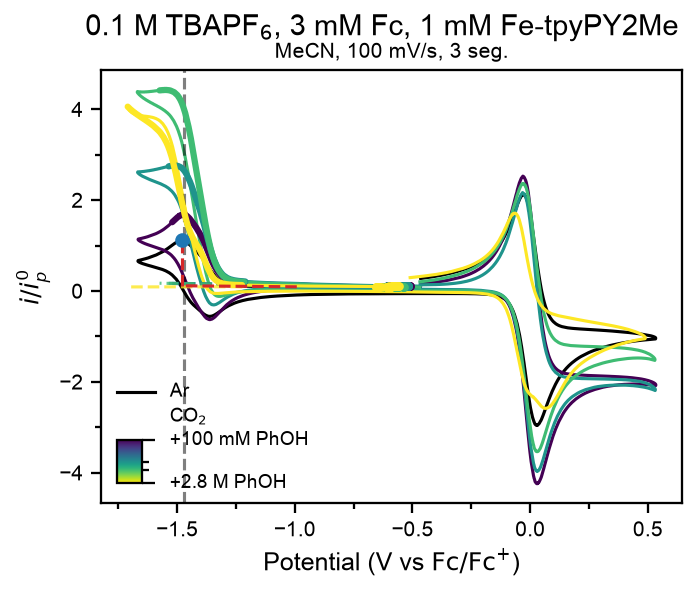

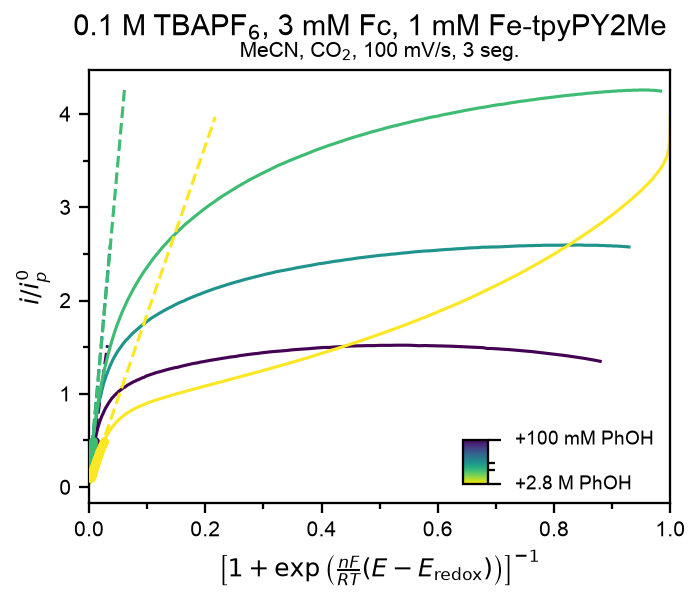

In [11]:
fowa_table = e.fowa(phoh_co2, {
    "plot all": True,
    "non-catalytic cv": fe_ar[0],
    "redox mode": "manual",
    "redox potential": -1.47,
    "fit basis": "y",
    "fit range": [0.1, 0.5],
    "diagnostic y axis": "i/ip0",
    "min fit points": 50,
    "min r2": .95,
})

## Fit FOWA Rates With `fit_rate()`

The FOWA table is still a normal result table, so it can be passed directly into `fit_rate()`. Here the x-axis is auto-resolved from the PhOH concentration metadata and the y-axis is the FOWA-derived `kobs`. A log-log fit is a quick way to estimate the apparent concentration order across the titration.

Use this as an exploratory fit: check the FOWA status/R2 values, decide whether all concentrations belong in the same regime, and adjust `fit indices` before interpreting the slope.


Field,Value
Model,linear
Equation,y = m x + b
Fit Parameters,"m, b (2)"
Residual,direct
X Range,-1.000 to 0.4472
Fit Points,4
R²,0.2168
RMSE,0.4209
m,-0.4220 ± 0.5672
b,3.099 ± 0.3188


,Compounds,Reference CV,ip0 Source,Redox Source,Reference Ep,Redox Mode,Redox Delta E,Redox Potential,Catalytic Ecat/2,Ecat/2 - E1/2,...,y label,y raw,y adjusted,y0,y mode,x transformed,y transformed,x transform,y transform,y transform note
0,100 mM PhOH,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_t...,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_t...,manual,None,manual,None,-1.47,None,None,...,kobs,1594.137686,1594.137686,1594.137686,raw,-1.000000,3.202526,log10,log10,
1,560 mM PhOH,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_t...,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_t...,manual,None,manual,None,-1.47,None,None,...,kobs,3703.836251,3703.836251,1594.137686,raw,-0.251812,3.568652,log10,log10,
2,1 M PhOH,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_t...,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_t...,manual,None,manual,None,-1.47,None,None,...,kobs,3668.957065,3668.957065,1594.137686,raw,0.000000,3.564543,log10,log10,
3,2.8 M PhOH,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_t...,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_t...,manual,None,manual,None,-1.47,None,None,...,kobs,252.249528,252.249528,1594.137686,raw,0.447158,2.401830,log10,log10,


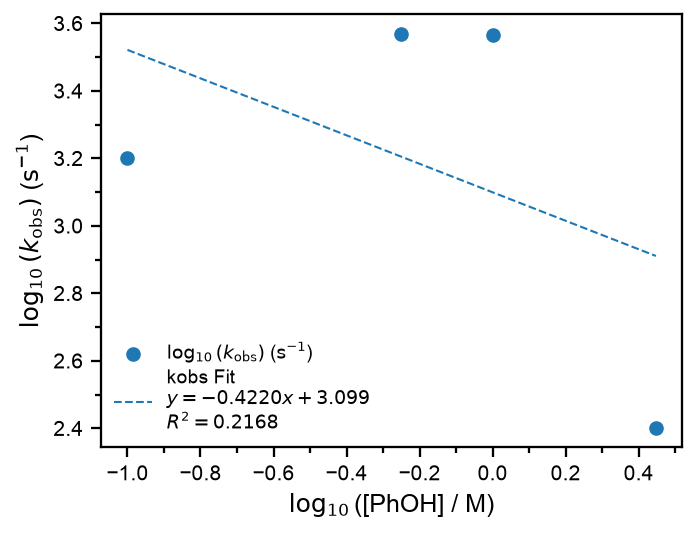

In [12]:
fowa_rate_fit = e.fit_rate(fowa_table, {
    "metric": "kobs",
    "species": "PhOH",
    "transform mode": "log-log",
    "plot": True,
    "plot fit": True,
    "fit label": True,
    "print": True,
})

fowa_rate_fit.table


## Manual Tafel-Style Analysis

`tafel_analysis()` converts a `TOFmax` value, a thermodynamic potential, and a catalyst redox potential into a Tafel-style `log10(TOF)` vs overpotential curve. A single CV gives one curve; a list of CVs gives one curve per input and reuses the same labels, colors, gradients, legends, and colorbars as `multiplot()`.

The redox potential below is the Fe redox potential used in the FOWA section. Set `CO2_TO_CO_THERMO_POTENTIAL` from the literature value and reference convention you want to use before interpreting the overpotential axis.


Parameter,Symbol,Value
Maximum Turnover Frequency,TOFmax,1000. s^-1
Thermodynamic Potential,Ethermo,-1.200 V
Redox Potential,Eredox,-1.470 V
Temperature,T,298.0 K
Overpotential Range,η,0 to 1 V


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Metric,Value
Label,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mMPhOH_-1.2_to_1V_100mVs
TOFmax,1000. s^-1
Temperature,298.0 K
Thermodynamic Potential,-1.200 V
Redox Potential,-1.470 V


,Index,Label,TOFmax,Temperature,Thermodynamic Potential,Redox Potential
0,0,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mM...,1000.0,298,-1.2,-1.47


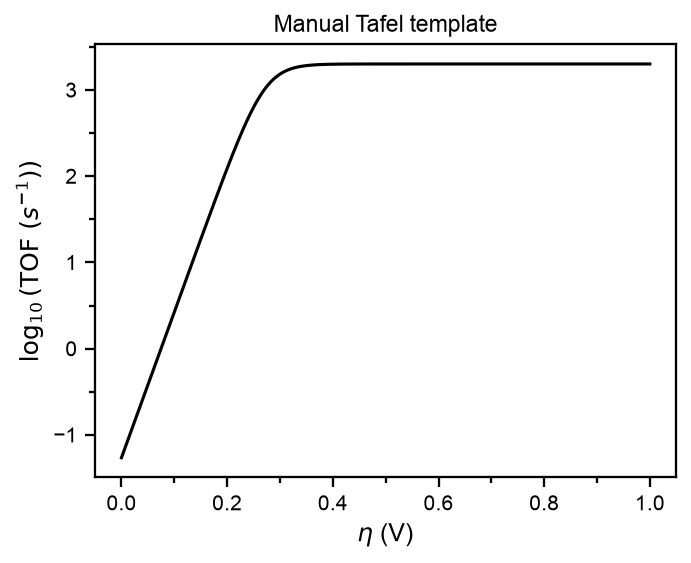

In [13]:
FE_REDOX_POTENTIAL = -1.47
CO2_TO_CO_THERMO_POTENTIAL = -1.20  # V vs Fc/Fc+; replace with your chosen literature convention

manual_tafel = e.tafel_analysis(
    phoh_co2[0],
    TOF_max=1000,
    thermodynamic_potential=CO2_TO_CO_THERMO_POTENTIAL,
    redox_potential=FE_REDOX_POTENTIAL,
    options={"color": "black"},
)
plt.gca().set_title("Manual Tafel template")

manual_tafel["summary"]


## Tafel-Style Curves From All FOWA Rates

The FOWA table gives one `TOFmax` value for each PhOH concentration. Passing the whole `phoh_co2` list and the matching `TOFmax` values lets `tafel_analysis()` draw the full concentration series in one call.

Because this uses the same backend style helpers as `multiplot()`, the familiar overlay options work here too: labels, label alterations, discrete colors, gradients, colorbars, legend placement, titles, subtitles, and scale bars.


Parameter,Symbol,Value
Maximum Turnover Frequency,TOFmax,per CV
Thermodynamic Potential,Ethermo,-1.200 V
Redox Potential,Eredox,-1.470 V
Temperature,T,298.0 K
Overpotential Range,η,0 to 1 V


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Index,Label,TOFmax,Temperature,Thermodynamic Potential,Redox Potential
0,100 mM PhOH,1594. s^-1,298.0 K,-1.200 V,-1.470 V
1,560 mM PhOH,3704. s^-1,298.0 K,-1.200 V,-1.470 V
2,1 M PhOH,3669. s^-1,298.0 K,-1.200 V,-1.470 V
3,2.8 M PhOH,252.2 s^-1,298.0 K,-1.200 V,-1.470 V


,Index,Label,TOFmax,Temperature,Thermodynamic Potential,Redox Potential
0,0,100 mM PhOH,1594.137686,298,-1.2,-1.47
1,1,560 mM PhOH,3703.836251,298,-1.2,-1.47
2,2,1 M PhOH,3668.957065,298,-1.2,-1.47
3,3,2.8 M PhOH,252.249528,298,-1.2,-1.47


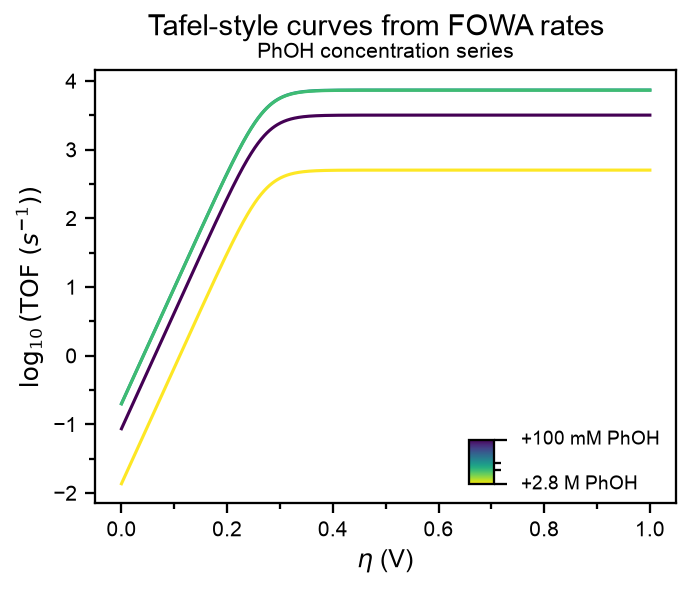

In [14]:
fowa_rates = fowa_table.table.attrs["full_results_df"].reset_index(drop=True)

fowa_tafel = e.tafel_analysis(
    phoh_co2,
    TOF_max=fowa_rates["TOFmax"],
    thermodynamic_potential=CO2_TO_CO_THERMO_POTENTIAL,
    redox_potential=FE_REDOX_POTENTIAL,
    options={
        "title": "Tafel-style curves from FOWA rates",
        "subtitle": "PhOH concentration series",
        "gradient by": "concentration",
        "gradient species": "PhOH",
        "legend mode": "colorbar",
        "colorbar tick labels": "endpoints",
    },
)

fowa_tafel["summary"]
